In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [2]:
citizens, _ = make_blobs(n_samples=300, centers=5, n_features=2, cluster_std=0.8, random_state=42)
citizens.shape

(300, 2)

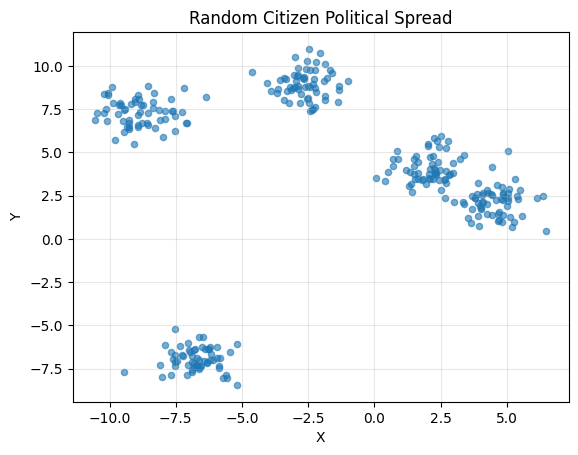

In [3]:
plt.scatter(citizens[:, 0], citizens[:, 1], alpha=0.6, s=20)
plt.title('Random Citizen Political Spread', fontsize=12)
plt.xlabel('X'); 
plt.ylabel('Y')
plt.grid(True, alpha=0.3)

# GMM

In [4]:
def draw_ellipse(position, covariance, ax, **kwargs):
    U, s, Vt = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2*np.sqrt(s)
    for nsig in range(1, 3):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height, angle=angle, alpha=0.3, **kwargs))

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",3
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


array([[ 1.19230401,  5.08750428],
       [-7.77796326,  0.02668553]])

array([0.60790599, 0.39209401])

array([[9.99917093e-01, 8.29067886e-05],
       [9.99996105e-01, 3.89475759e-06],
       [9.98358312e-01, 1.64168822e-03],
       [9.99999999e-01, 6.29157646e-10],
       [9.90772613e-01, 9.22738703e-03]])

Text(0, 0.5, 'Y')

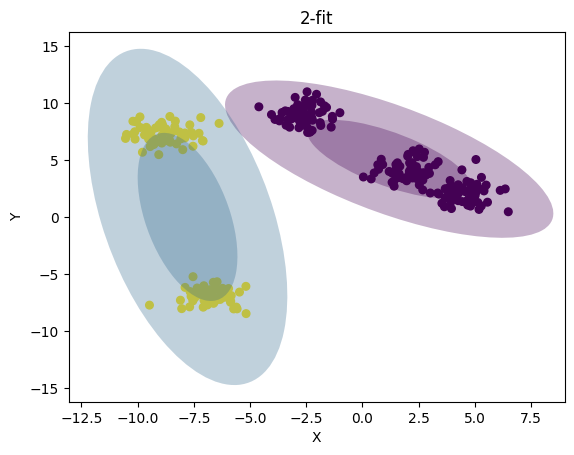

In [35]:
n = 2
gmm = GaussianMixture(n_components=n, covariance_type='full', reg_covar=3, random_state=42)
display(gmm.fit(citizens))
display(gmm.means_)
display(gmm.weights_)
display(gmm.predict_proba(citizens)[0:5])

fig, ax = plt.subplots()
ax.scatter(citizens[:, 0], citizens[:, 1], c=gmm.fit_predict(citizens), s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, 2*n))
for k in range(n):
    draw_ellipse(gmm.means_[k], gmm.covariances_[k], ax, fc=colors[k])
ax.set_title('2-fit')
ax.set_xlabel('X')
ax.set_ylabel('Y')

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",3
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


array([[ 3.23264025,  3.15200254],
       [-5.7505377 ,  8.11944014],
       [-6.72493927, -6.95157001]])

array([0.40303487, 0.39696513, 0.2       ])

array([[4.48865179e-02, 9.55113482e-01, 7.81622072e-19],
       [9.75088837e-01, 2.49111628e-02, 2.94124416e-13],
       [6.35696519e-02, 9.36430348e-01, 8.67080882e-15],
       [9.99988585e-01, 1.14148727e-05, 3.79597905e-14],
       [3.65956362e-03, 9.96340436e-01, 1.02003530e-17]])

Text(0, 0.5, 'Y')

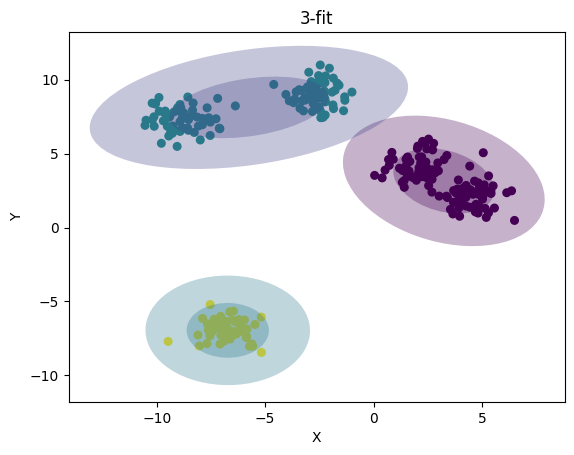

In [37]:
n = 3
gmm = GaussianMixture(n_components=n, covariance_type='full', reg_covar=3, random_state=42)
display(gmm.fit(citizens))
display(gmm.means_)
display(gmm.weights_)
display(gmm.predict_proba(citizens)[0:5])

fig, ax = plt.subplots()
ax.scatter(citizens[:, 0], citizens[:, 1], c=gmm.fit_predict(citizens), s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, 2*n))
for k in range(n):
    draw_ellipse(gmm.means_[k], gmm.covariances_[k], ax, fc=colors[k])
ax.set_title('3-fit')
ax.set_xlabel('X')
ax.set_ylabel('Y')

,"n_components n_components: int, default=1The number of mixture components.",6
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",3
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


array([[ 3.2994713 ,  3.09409473],
       [-8.79583697,  7.31920278],
       [-6.72493927, -6.95157001],
       [-2.68627598,  8.91698522],
       [ 3.18927696,  3.18606074],
       [ 3.21111006,  3.16780476]])

array([0.20200698, 0.19892328, 0.2       , 0.19950219, 0.07470842,
       0.12485913])

array([[1.18966553e-02, 7.58172041e-04, 5.28235165e-19, 9.72647642e-01,
        5.67922510e-03, 9.01830555e-03],
       [4.69321117e-01, 1.06382993e-05, 2.97300943e-13, 3.60307853e-02,
        1.86803247e-01, 3.07834213e-01],
       [1.94233731e-02, 9.68296118e-03, 6.62373847e-15, 9.47179727e-01,
        9.14650443e-03, 1.45674345e-02],
       [5.11803312e-01, 2.59123764e-11, 3.75024873e-14, 4.80364913e-06,
        1.81809361e-01, 3.06382524e-01],
       [1.18211309e-03, 2.84958305e-02, 9.40661777e-18, 9.68726278e-01,
        6.24446793e-04, 9.71332047e-04]])

Text(0, 0.5, 'Y')

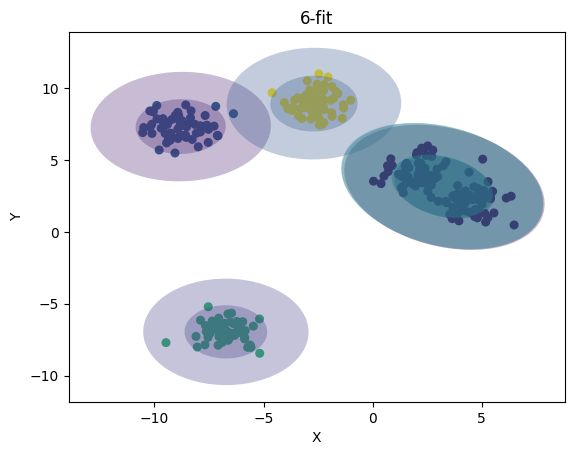

In [38]:
n = 6
gmm = GaussianMixture(n_components=n, covariance_type='full', reg_covar=3, random_state=42)
display(gmm.fit(citizens))
display(gmm.means_)
display(gmm.weights_)
display(gmm.predict_proba(citizens)[0:5])

fig, ax = plt.subplots()
ax.scatter(citizens[:, 0], citizens[:, 1], c=gmm.fit_predict(citizens), s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, 2*n))
for k in range(n):
    draw_ellipse(gmm.means_[k], gmm.covariances_[k], ax, fc=colors[k])
ax.set_title('6-fit')
ax.set_xlabel('X')
ax.set_ylabel('Y')

,"n_components n_components: int, default=1The number of mixture components.",10
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",3
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


array([[ 3.3206426 ,  3.0767169 ],
       [-8.80526457,  7.31699279],
       [-6.72493927, -6.95157001],
       [-2.68946741,  8.91549566],
       [-8.80811306,  7.31666448],
       [ 3.17423148,  3.19811577],
       [-2.68026965,  8.91943119],
       [ 3.13259678,  3.23351388],
       [ 3.36534216,  3.03971496],
       [-8.74926124,  7.32986332]])

array([0.1376512 , 0.06114785, 0.2       , 0.11404121, 0.08896798,
       0.13772592, 0.08530666, 0.05767688, 0.06855053, 0.04893179])

array([[7.72487140e-03, 2.15523959e-04, 5.28303909e-19, 5.54840875e-01,
        3.06609449e-04, 1.06855965e-02, 4.17539745e-01, 4.92413279e-03,
        3.48545080e-03, 2.77194855e-04],
       [3.15161962e-01, 2.98991338e-06, 2.97337171e-13, 2.06290014e-02,
        4.23841306e-06, 3.47418578e-01, 1.54028819e-02, 1.49310352e-01,
        1.52065870e-01, 4.12615011e-06],
       [1.26354192e-02, 2.83380089e-03, 6.62302790e-15, 5.40351483e-01,
        4.06491230e-03, 1.72010533e-02, 4.06265870e-01, 7.87736321e-03,
        5.72360549e-03, 3.04649197e-03],
       [3.51265471e-01, 6.85049274e-12, 3.74974434e-14, 2.78911253e-06,
        9.54205178e-12, 3.33693056e-01, 2.01271379e-06, 1.37515099e-01,
        1.77521573e-01, 1.37555465e-11],
       [7.53042296e-04, 8.42321107e-03, 9.40730567e-18, 5.53051170e-01,
        1.21183275e-02, 1.18132005e-03, 4.15052711e-01, 5.65408229e-04,
        3.27254091e-04, 8.52755518e-03]])

Text(0, 0.5, 'Y')

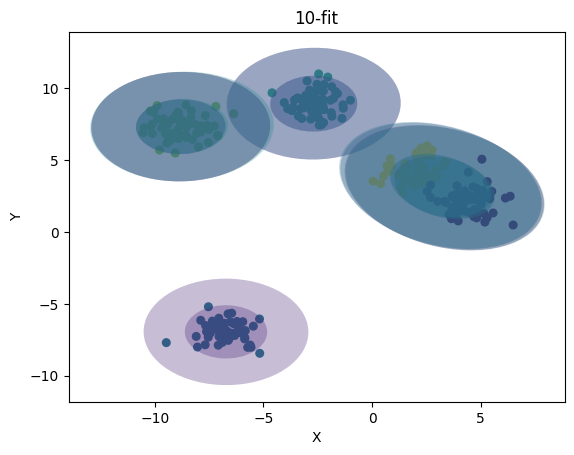

In [39]:
n = 10
gmm = GaussianMixture(n_components=n, covariance_type='full', reg_covar=3, random_state=42)
display(gmm.fit(citizens))
display(gmm.means_)
display(gmm.weights_)
display(gmm.predict_proba(citizens)[0:5])

fig, ax = plt.subplots()
ax.scatter(citizens[:, 0], citizens[:, 1], c=gmm.fit_predict(citizens), s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, 2*n))
for k in range(n):
    draw_ellipse(gmm.means_[k], gmm.covariances_[k], ax, fc=colors[k])

ax.set_title('10-fit')
ax.set_xlabel('X')
ax.set_ylabel('Y')